In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

df = pd.read_csv('../../../data/processed/telco_customer_churn_clean.csv')

## 1) ประเภท MutipleLine ต่อ Churn

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [2]:
pd.crosstab(df["MultipleLines"], df["Churn"], normalize="index")

Churn,No,Yes
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


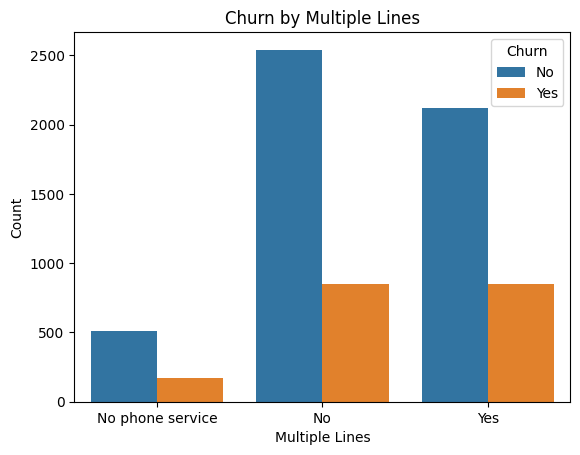

<Axes: xlabel='MultipleLines'>

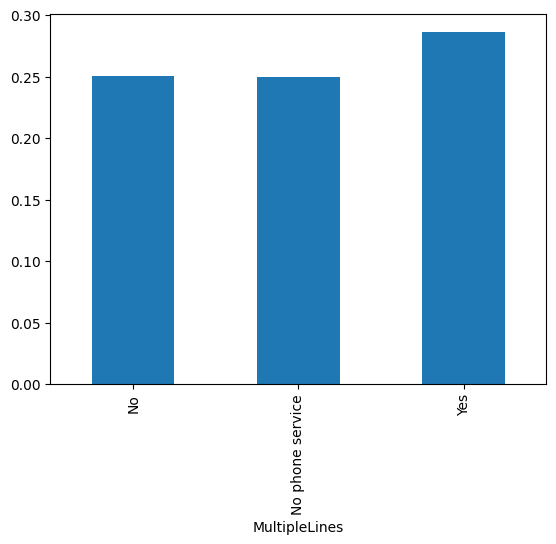

In [8]:
sns.countplot(data=df, x="MultipleLines", hue="Churn")
plt.title("Churn by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Count")
plt.legend(title="Churn", loc="upper right")
plt.show()


ct = pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
)

ct["Yes"].plot(kind="bar")


H1: Multiple Line มี Total Charge สูง

H2: Multiple Lines อาจมี Monthly Charges สูงกว่า
 
H3: Multiple Line อาจมี สัญญา Contract นานกว่า

H็4: Multiple Line อาจมี tenure สูงกว่า

H5: Multiple Lines อาจสัมพันธ์กับ Churn


#### TEST  Multiple Line มี Total Charge สูง

In [13]:
pd.crosstab(df["MultipleLines"], df["TotalCharges"], normalize="index")

TotalCharges,18.80,18.85,18.90,19.00,19.05,19.10,19.15,19.20,19.25,19.30,...,8477.70,8496.70,8529.50,8543.25,8547.15,8564.75,8594.40,8670.10,8672.45,8684.80
MultipleLines,,,,,,,,,,,,,,,,,,,,,
No,0.000295,0.000591,0.000295,0.000295,0.000295,0.000886,0.000295,0.001182,0.000886,0.001182,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
No phone service,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Yes,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000337,0.000337,0.000337,0.000337,0.000337,0.000337,0.000337,0.000337,0.000337,0.000337


TEST  Multiple Lines อาจมี Monthly Charges สูงกว่า

In [14]:
pd.crosstab(df["MultipleLines"], df["MonthlyCharges"], normalize="index")

MonthlyCharges,18.25,18.40,18.55,18.70,18.75,18.80,18.85,18.90,18.95,19.00,...,117.35,117.45,117.50,117.60,117.80,118.20,118.35,118.60,118.65,118.75
MultipleLines,,,,,,,,,,,,,,,,,,,,,
No,0.000295,0.000295,0.000295,0.00059,0.000295,0.002065,0.001475,0.00059,0.00177,0.002065,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
No phone service,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Yes,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,...,0.000337,0.000337,0.000337,0.000337,0.000337,0.000337,0.000337,0.000673,0.000337,0.000337


TEST  Multiple Line อาจมี สัญญา Contract นานกว่า

In [16]:
pd.crosstab(df["MultipleLines"], df["tenure_group"], normalize="index")

tenure_group,0-12,13-24,25-36,37-48,49-60,61-72
MultipleLines,,,,,,
No,0.432201,0.164549,0.116691,0.096012,0.091285,0.099261
No phone service,0.319118,0.132353,0.119118,0.126471,0.127941,0.175000
Yes,0.166835,0.127064,0.119987,0.118301,0.146950,0.320863


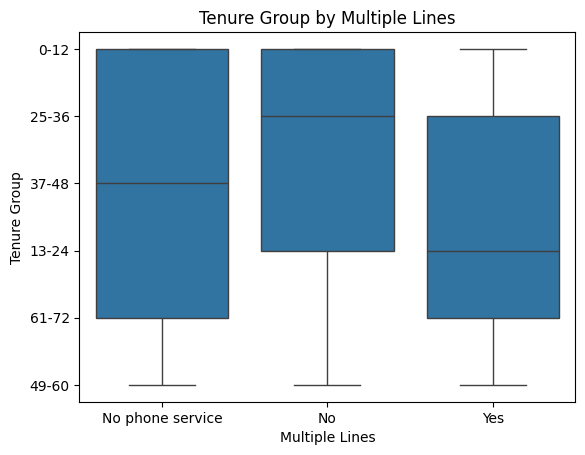

In [17]:
sns.boxplot(x="MultipleLines", y="tenure_group", data=df)
plt.title("Tenure Group by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Tenure Group")
plt.show()